In [125]:
import pandas as pan
import matplotlib.pyplot as plt
import numpy as np

f0  = pan.read_csv("../data/experimental2/filtered/f0.csv")
f1  = pan.read_csv("../data/experimental2/filtered/f1.csv")

In [96]:
f0

,n,action_name,motivation,feedback,nfeedback
0,1,weekly,-2,"Oui, mais pas sûr",0.7
1,1,monthly,2,Oui,1.0
2,1,as_usual,2,Oui,1.0
3,2,weekly,-3,Non,0.0
4,2,monthly,3,Oui,1.0
...,...,...,...,...,...
214,126,monthly,-1,Non,0.0
215,126,as_usual,2,Non,0.0
216,128,weekly,-2,"Oui, mais pas sûr",0.7
217,128,monthly,2,Oui,1.0


In [97]:
f1

,n,action_name,motivation,feedback,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,nfeedback
0,1,weekly,2,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,1,monthly,2,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,1,notatall,-1,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,2,weekly,1,"Oui, mais pas sûr",NaN,NaN,NaN,NaN,NaN,NaN,0.7
4,2,monthly,2,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...
208,126,monthly,-2,Non,NaN,NaN,NaN,NaN,NaN,NaN,0.0
209,126,notatall,-1,Non,NaN,NaN,NaN,NaN,NaN,NaN,0.0
210,128,weekly,2,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0
211,128,monthly,2,Oui,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [146]:
feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}


def compute_meanfeedback(df):
    feedbacks_per_motivation = {-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]}

    def update_feedbacks(row):
        if row["nfeedback"] != 0.8:
            feedbacks_per_motivation[row["motivation"]].append(row["nfeedback"])
    


    df["nfeedback"] = df["feedback"].map(feedback_map)
    df.apply(update_feedbacks,axis=1)
    meanfeedback_per_motivation = {k:sum(v)/len(v) for (k,v) in feedbacks_per_motivation.items()}
    feedbackerr_per_motvation = {k:np.std(v)/(np.sqrt(len(v)))for (k,v) in feedbacks_per_motivation.items()}
    x,y = [],[]
    for (k,v) in feedbacks_per_motivation.items():
        for j in v:
            x.append(k)
            y.append(j)
    model = np.polyfit(x,y,deg = 3)
    return meanfeedback_per_motivation,feedbackerr_per_motvation,model

def plotting(meandic,errdic,model):
    meandic_items = meandic.items()
    x = [d[0]for d in meandic_items]
    y = [d[1]for d in meandic_items]
    err = [d[1] for d in errdic.items()]
    plt.errorbar(x,y,yerr=err,label="réalisation moyenne (avec sem)")
    x = np.linspace(-3,3,50)
    y = [np.polyval(model, i) for i in x]
    plt.plot(x,y,label = "modèle cubique")

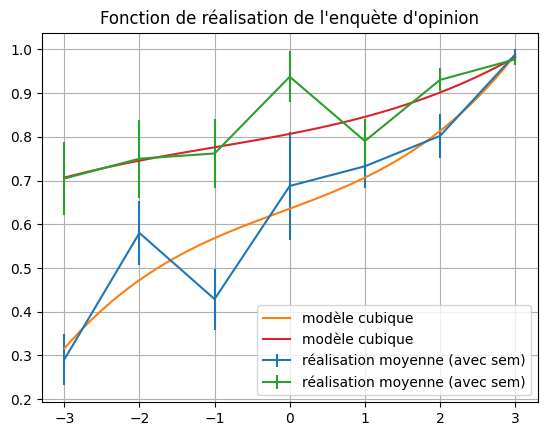

In [148]:
mf0,ef0,model0 = compute_meanfeedback(f0)
mf1,ef1,model1 = compute_meanfeedback(f1)


plotting(mf0,ef0,model0)
plotting(mf1,ef1,model1)
plt.title("Fonction de réalisation de l'enquète d'opinion")
plt.legend()
plt.grid(visible=True)